In [1]:
%load_ext autoreload
%autoreload 2

# ODE Validation

In [2]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import h5py

In [3]:
ode = Trajectory1PAT1R()

In [4]:
with h5py.File("ForcingTermsWaSABI1PAT1R.h5", "r") as trajectoryData:
    p, m1, m2, chi1, chi2, deltaM = np.array(trajectoryData["Grid"][:]).T
    dOmegadp = -3./2.*p**(-5./2.)
    nu = m1*m2/(m1+m2)**2.
    FOmega_WaSABI = np.array(trajectoryData["dOmega/dt"][:])
    Fp_WaSABI = FOmega_WaSABI/dOmegadp
    Omega_WaSABI = np.array(trajectoryData["dphi/dt"][:])
    Fnu_WaSABI = np.array(trajectoryData["dnu/dt"][:])
    FdeltaM_WaSABI = np.array(trajectoryData["ddeltam/dt"][:])
    Fchit1_WaSABI = np.array(trajectoryData["dchit1/dt"][:])
    N_TESTS = len(p)

In [5]:
ode_values = []
for i in range(N_TESTS):
    ode.add_fixed_parameters(m1[i], m2[i], chi1[i], [chi2[i]])
    ode_values.append(ode.evaluate_rhs([p[i], 0.0, 1.0, 0.0, 0.0, 0.0, deltaM[i], 0.0]))
ode_values = np.array(ode_values)

Fp_RelativeError = np.abs(1 - nu*ode_values[:,0]/Fp_WaSABI)
FdeltaM_RelativeError = np.abs(1 - nu*ode_values[:,-2]/FdeltaM_WaSABI)
Fchit1_RelativeError = np.abs(1 - nu*ode_values[:,-1]/Fchit1_WaSABI)

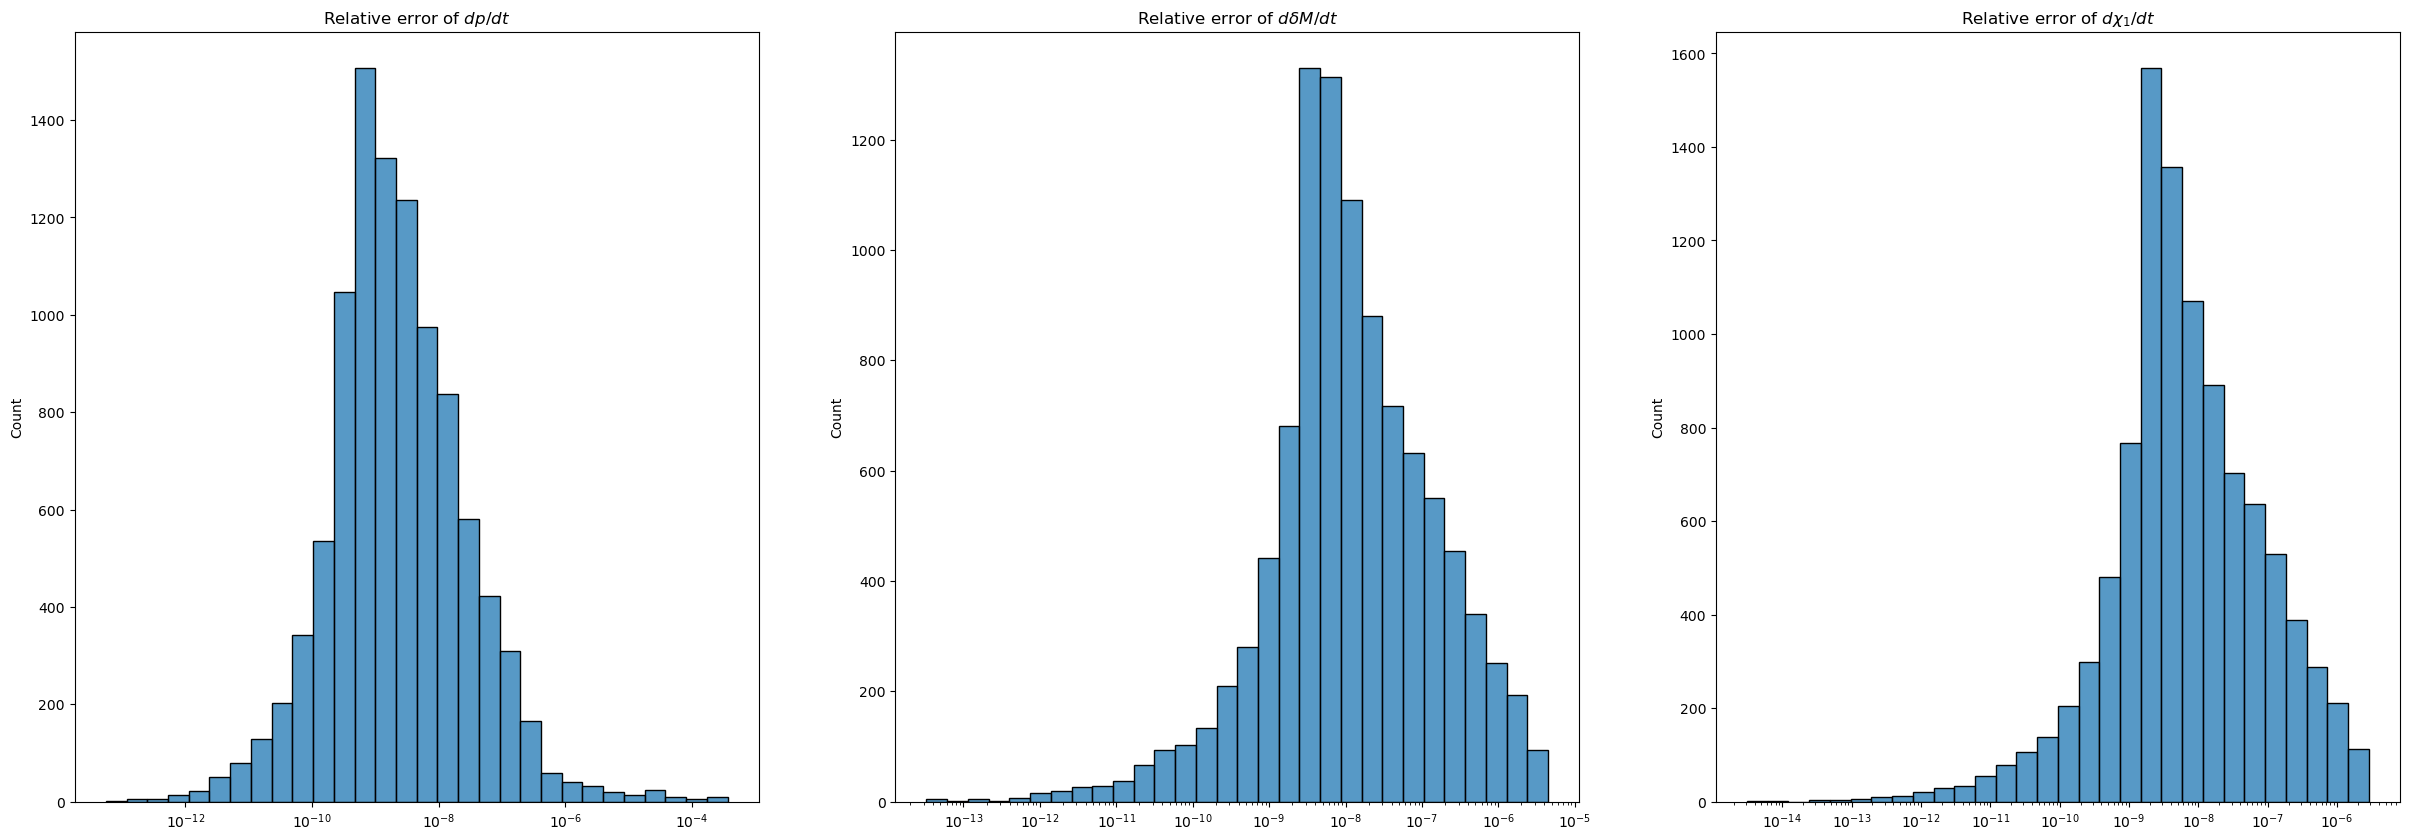

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(30,10))

sns.histplot(Fp_RelativeError, bins=30, log_scale=True, ax=axs[0])
axs[0].set(title=rf'Relative error of $dp/dt$')
sns.histplot(FdeltaM_RelativeError, bins=30, log_scale=True, ax=axs[1])
axs[1].set(title=rf'Relative error of $d\delta M/dt$')
sns.histplot(Fchit1_RelativeError, bins=30, log_scale=True, ax=axs[2])
axs[2].set(title=rf'Relative error of $d\chi_1/dt$')

plt.show()

# Trajectory Validation

In [8]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
from few.summation.interpolatedmodesum import CubicSplineInterpolant
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import h5py

In [17]:
with h5py.File("TrajectoryWaSABI1PAT1R.h5", "r") as trajectoryData:
    p0, m10, m20, chi10, chi20, chit10 = np.array(trajectoryData["Grid"][:]).T
    dOmegadp = -3./2.*p0**(-5./2.)
    nu = m10*m20/(m10+m20)**2.
    t_WaSABI = np.array(trajectoryData["t"][:])
    Omega_WaSABI = np.array(trajectoryData["Omega"][:])
    p_WaSABI = Omega_WaSABI**(-2./3.)
    phi_WaSABI = np.array(trajectoryData["phi"][:])
    nu_WaSABI = np.array(trajectoryData["nu"][:])
    M_WaSABI = np.array(trajectoryData["M"][:])
    chit1_WaSABI = np.array(trajectoryData["chit1"][:])
    chit2_WaSABI = np.array(trajectoryData["chit2"][:])
    deltaM_WaSABI = np.array(trajectoryData["deltam"][:])
    N_TESTS = len(p0)

deltachit1_WaSABI = chit1_WaSABI - chit10

T=1e15
dt=1.0

In [18]:
p_FEW = np.array([])
Omega_FEW = np.array([])
deltaM_FEW = np.array([])
deltachit1_FEW = np.array([])
phi_FEW = np.array([])

traj = EMRIInspiral(func=Trajectory1PAT1R)

for i in range(N_TESTS):
    t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj(
        m10[i], m20[i],
        chi10[i],        # chi1 (primary spin)
        p0[i],
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi20[i],
        T=T,
        dt=dt,
        in_coordinate_time=False,
    )
    # Create a cubic spline interpolant for the trajectory
    t_spl = traj.integrator_spline_t
    p_coeff_spl = traj.integrator_spline_coeff[:, 0, :]

    # Example: Interpolate the semi-latus rectum (p)
    spline_p = CubicSplineInterpolant(t,p)
    spline_phi = CubicSplineInterpolant(t,Phi_phi)

    p_FEW = np.append(p_FEW, spline_p(t_WaSABI[i]))
    Omega_FEW = np.append(Omega_FEW, spline_phi(t_WaSABI[i]))
    deltaM_FEW = np.append(deltaM_FEW, np.interp(t_WaSABI[i], t, deltaM))
    deltachit1_FEW = np.append(deltachit1_FEW, np.interp(t_WaSABI[i], t, deltachit1))
    phi_FEW = np.append(phi_FEW, np.interp(t_WaSABI[i], t, Phi_phi))

In [20]:
p_RelativeError = np.abs((p_FEW - p_WaSABI) / p_WaSABI)
deltaM_RelativeError = np.abs((deltaM_FEW - deltaM_WaSABI) / deltaM_WaSABI)
chit1_RelativeError = np.abs((deltachit1_FEW - deltachit1_WaSABI) / deltachit1_WaSABI)
phi_RelativeError = np.abs((phi_FEW - phi_WaSABI) / phi_WaSABI)
phi_AbsoluteError = np.abs(phi_FEW - phi_WaSABI)

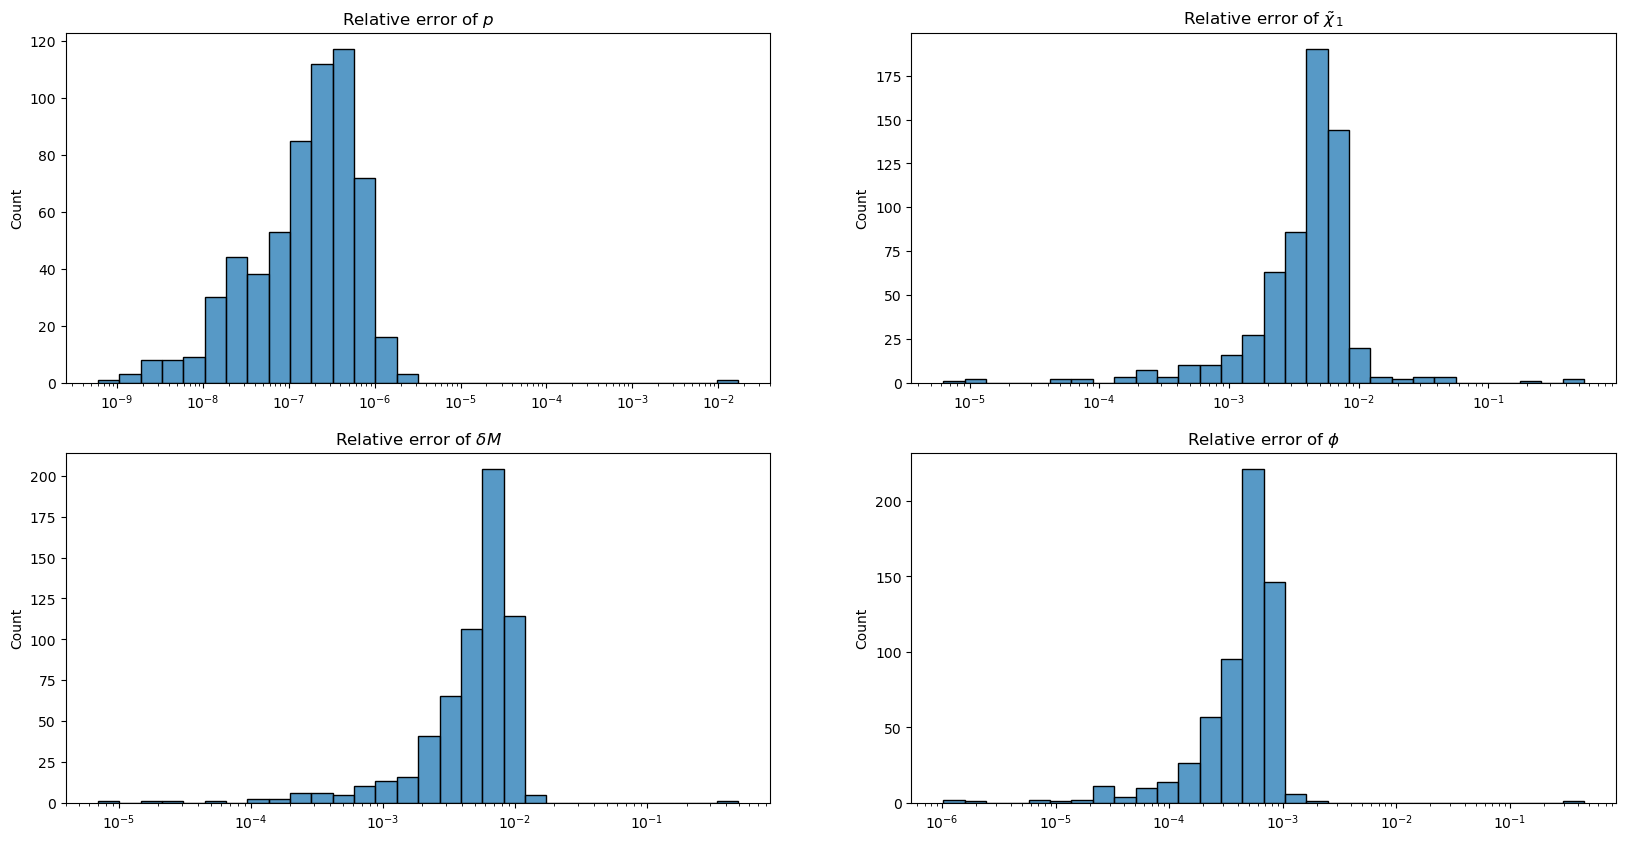

In [21]:
fig, axs = plt.subplots(2,2,figsize=(20,10))

sns.histplot(p_RelativeError, bins=30, log_scale=True, ax=axs[0, 0])
axs[0, 0].set(title=rf'Relative error of $p$')
sns.histplot(deltaM_RelativeError, bins=30, log_scale=True, ax=axs[1, 0])
axs[1, 0].set(title=rf'Relative error of $\delta M$')
sns.histplot(chit1_RelativeError, bins=30, log_scale=True, ax=axs[0, 1])
axs[0, 1].set(title=rf'Relative error of $\tilde\chi_1$')
sns.histplot(phi_RelativeError, bins=30, log_scale=True, ax=axs[1, 1])
axs[1, 1].set(title=rf'Relative error of $\phi$')

plt.show()

<Axes: ylabel='Count'>

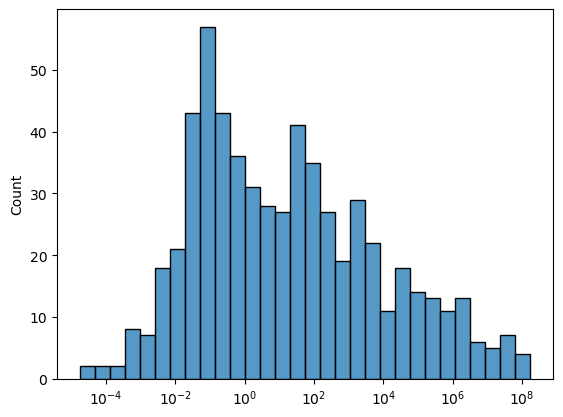

In [22]:
sns.histplot(phi_AbsoluteError, bins=30, log_scale=True)

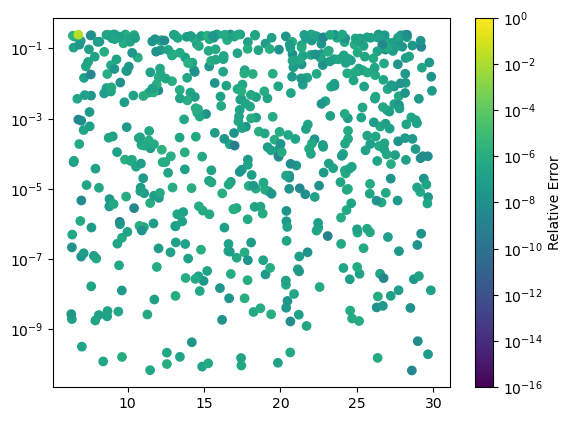

In [23]:
plt.scatter(p0, nu, c=p_RelativeError, cmap='viridis', norm='log')
#plt.ylim(1e-4,.25)
plt.clim(1e-16,1e-0)
plt.colorbar(label='Relative Error')
plt.yscale("log")

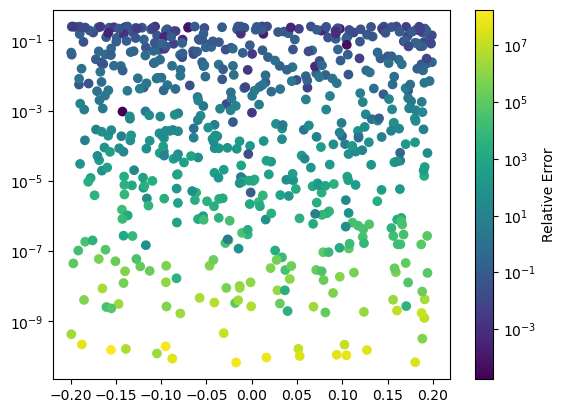

In [26]:
plt.scatter(chi10, nu, c=phi_AbsoluteError, cmap='viridis', norm='log')
#plt.ylim(1e-2,.25)
#plt.clim(1e-16,1e-1)
plt.colorbar(label='Relative Error')
plt.yscale("log")

# Dephasing

In [28]:
t_WaSABI = []
p_WaSABI = []
phi_WaSABI = []

with h5py.File("PhaseWaSABI1PAT1R.h5", "r") as trajectoryData:
    p0, m10, m20, chi10, chi20, chit10 = np.array(trajectoryData["Grid"][:]).T
    N_TESTS = len(p0)

    nu = m10*m20/(m10+m20)**2.

    for i in range(N_TESTS):
        t_WaSABI.append(np.array(trajectoryData[str(i+1)][0, :]))
        p_WaSABI.append(np.array(trajectoryData[str(i+1)][1, :]))
        phi_WaSABI.append(np.array(trajectoryData[str(i+1)][2, :]))

T=1e15
dt=1.0

In [29]:
phi_FEW = []
p_FEW = []

traj = EMRIInspiral(func=Trajectory1PAT1R)

for i in range(N_TESTS):
    t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj(
        m10[i], m20[i],
        chi10[i],        # chi1 (primary spin)
        p0[i],
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi20[i],
        T=T,
        dt=dt,
        in_coordinate_time=False,
    )

    # Example: Interpolate the semi-latus rectum (p)
    spline_phi = CubicSplineInterpolant(t,Phi_phi)
    spline_p = CubicSplineInterpolant(t,p)
    phi_FEW.append(spline_phi(t_WaSABI[i]))
    p_FEW.append(spline_p(t_WaSABI[i]))

In [32]:
deltaphi = []

for i in range(N_TESTS):
    deltaphi.append(np.abs(phi_FEW[i] - phi_WaSABI[i]))

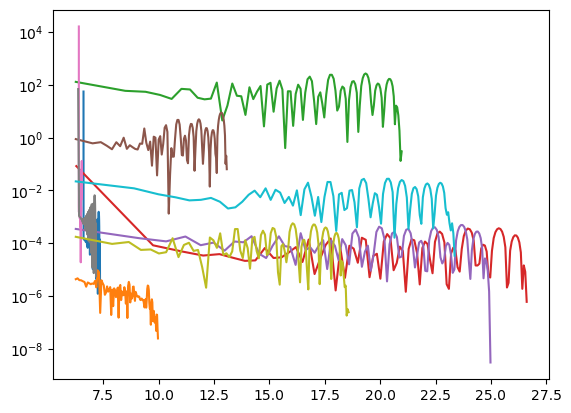

In [33]:
for i in range(10):
    plt.plot(p_FEW[i], deltaphi[i])
plt.yscale("log")
plt.show()

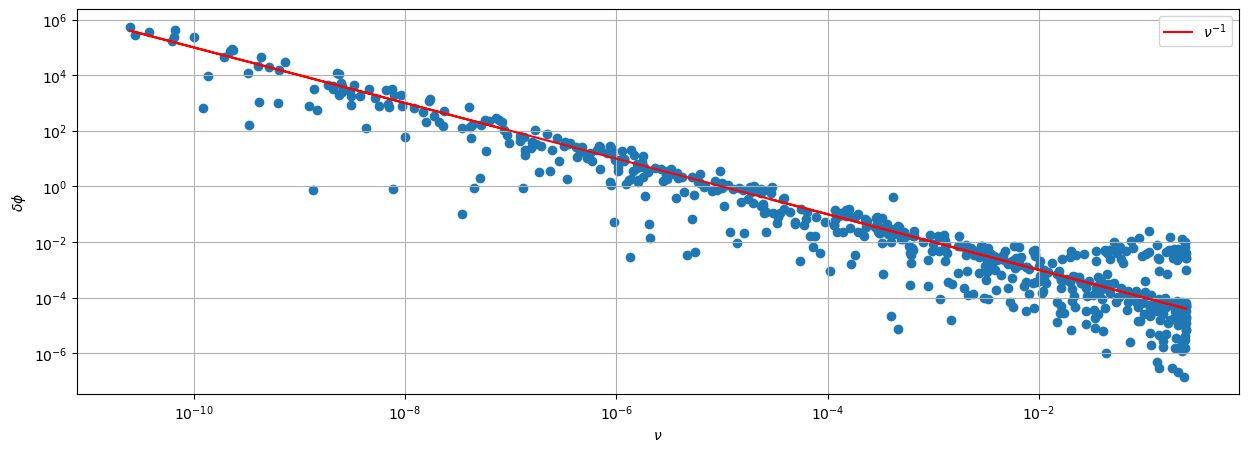

In [34]:
plt.figure(figsize=(15,5))
plt.scatter(nu, [np.mean(deltaphi[i]) for i in range(N_TESTS)])
plt.plot(nu, 1e-5 * nu**(-1),c='r',label=r'$\nu^{-1}$')
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r'$\nu$')
plt.ylabel(r'$\delta \phi$')
plt.legend()
plt.grid()
plt.show()